/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. 

  Preprocessing Strategy  Accuracy  Precision  Recall  F1-score
0               Raw Data    0.8046        0.0     0.0       0.0
1            Scaled Data    0.8046        0.0     0.0       0.0


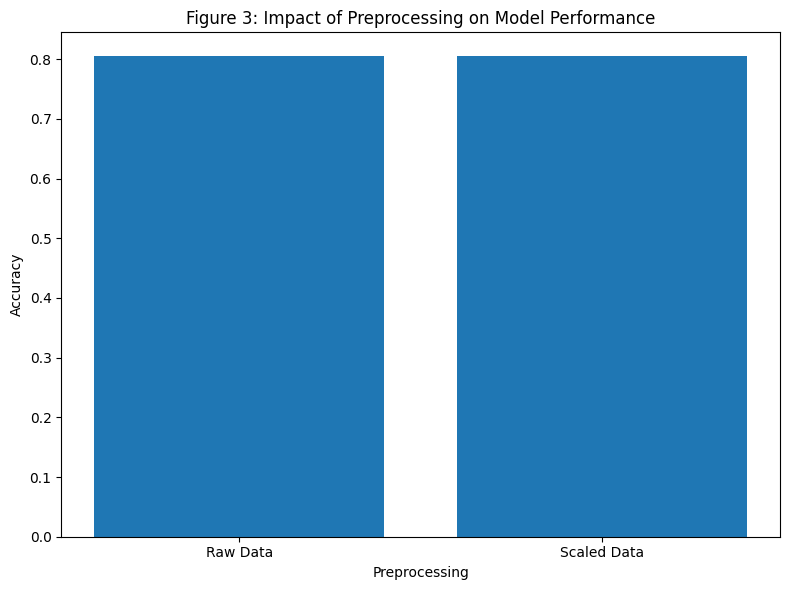

Saved: RQ3_table.csv and RQ3_figure.pdf


In [1]:
# ==========================================
# RQ3: Effect of Preprocessing
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Load dataset
df = pd.read_csv(
    "/kaggle/input/datasets/sampath1092003/netflix-user-behavior-analysis-dataset/netflix_user_behavior_dataset.csv"
)

# Drop user_id
df.drop("user_id", axis=1, inplace=True)

# Encode categorical variables
for col in df.select_dtypes(include="object").columns:
    df[col] = LabelEncoder().fit_transform(df[col])

X = df.drop("churned", axis=1)
y = df["churned"]

results = []

# ------------------------------------------
# Method 1: Raw Data
# ------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LogisticRegression(max_iter=500)

model.fit(X_train, y_train)
pred = model.predict(X_test)

results.append([
    "Raw Data",
    accuracy_score(y_test, pred),
    precision_score(y_test, pred),
    recall_score(y_test, pred),
    f1_score(y_test, pred)
])

# ------------------------------------------
# Method 2: Scaled Data
# ------------------------------------------

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

model.fit(X_train, y_train)
pred = model.predict(X_test)

results.append([
    "Scaled Data",
    accuracy_score(y_test, pred),
    precision_score(y_test, pred),
    recall_score(y_test, pred),
    f1_score(y_test, pred)
])

# Create results table
results_df = pd.DataFrame(
    results,
    columns=[
        "Preprocessing Strategy",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score"
    ]
)

print(results_df)

# Save table
results_df.to_csv(
    "/kaggle/working/RQ3_table.csv",
    index=False
)

# Plot figure
plt.figure(figsize=(8,6))

plt.bar(
    results_df["Preprocessing Strategy"],
    results_df["Accuracy"]
)

plt.xlabel("Preprocessing")
plt.ylabel("Accuracy")
plt.title("Figure 3: Impact of Preprocessing on Model Performance")

plt.tight_layout()

plt.savefig(
    "/kaggle/working/RQ3_figure.pdf"
)

plt.show()

print("Saved: RQ3_table.csv and RQ3_figure.pdf")